# Análisis del dataset DNU — Xenofobia y racismo en Twitter

Natalia Debandi

## Contexto de recolección

Este dataset fue recolectado de forma complementaria  al dataset deL PIUBAMAS durante la pandemia de COVID-19, utilizando la API pública de Twitter (en ese momento de acceso abierto) desde R.

**Filtros de búsqueda:** `DNU`, `extranjeros`, `antecedentes`, `expulsión`, `delincuente`

A diferencia del dataset principal, **no se aplicó ningún filtro por cuenta de medios**: los tweets provienen directamente de usuarios de la API.

## Clasificación automática

Se aplicó el modelo [`piuba-bigdata/beto-contextualized-hate-speech`](https://huggingface.co/piuba-bigdata/beto-contextualized-hate-speech) para clasificar cada tweet en las siguientes categorías de discurso de odio:

| Etiqueta | Descripción |
|----------|-------------|
| `CALLS` | Llamados a la acción |
| `WOMEN` | Odio hacia mujeres |
| `LGBTI` | Odio hacia la comunidad LGBTI |
| `RACISM` | Racismo / xenofobia |
| `CLASS` | Odio por clase social |
| `POLITICS` | Odio político |
| `DISABLED` | Odio hacia personas con discapacidad |
| `APPEARANCE` | Odio por apariencia física |
| `CRIMINAL` | Criminalización del otro |

El modelo fue aplicado con **contexto vacío**, usando el texto del tweet como único input.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Estilo visual consistente
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = sns.color_palette('tab10')

LABELS = ['CALLS', 'WOMEN', 'LGBTI', 'RACISM', 'CLASS',
          'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL']

df = pd.read_csv('DNU_Data/tweets_clasificados.csv', low_memory=False)
df['fecha']     = pd.to_datetime(df['fecha'], utc=True)
df['fecha_dia'] = pd.to_datetime(df['fecha_dia']).dt.date
df[LABELS]      = df[LABELS].astype(int)

print(f'Dataset cargado: {len(df):,} tweets')

Dataset cargado: 259,752 tweets


## Cobertura temporal

La siguiente tabla muestra la cantidad de tweets recolectados por día.

In [2]:
por_dia = (
    df.groupby('fecha_dia')
      .size()
      .reset_index(name='tweets')
      .sort_values('fecha_dia')
)
por_dia['fecha_dia'] = pd.to_datetime(por_dia['fecha_dia'])
por_dia['acumulado'] = por_dia['tweets'].cumsum()
por_dia['% del total'] = (por_dia['tweets'] / por_dia['tweets'].sum() * 100).round(1)

print(f"Primer día : {por_dia['fecha_dia'].min().date()}")
print(f"Último día : {por_dia['fecha_dia'].max().date()}")
print(f"Total días : {len(por_dia)}")
print(f"Total tweets: {por_dia['tweets'].sum():,}")
print()

display(
    por_dia
    .assign(**{'fecha_dia': por_dia['fecha_dia'].dt.strftime('%d %b %Y')})
    .set_index('fecha_dia')
    .style
    .format({'tweets': '{:,}', 'acumulado': '{:,}', '% del total': '{:.1f}%'})
    .background_gradient(subset=['tweets'], cmap='Blues')
    .set_caption('Tweets recolectados por día')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]
    }])
)

Primer día : 2021-03-05
Último día : 2021-03-09
Total días : 5
Total tweets: 259,752



,tweets,acumulado,% del total
fecha_dia,,,
05 Mar 2021,"106,851","106,851",41.1%
06 Mar 2021,"80,224","187,075",30.9%
07 Mar 2021,"37,339","224,414",14.4%
08 Mar 2021,"35,160","259,574",13.5%
09 Mar 2021,178,"259,752",0.1%


Clasificación de Tweets

In [3]:
counts = df[LABELS].sum().sort_values(ascending=False)
pcts   = (counts / len(df) * 100).round(1)

tabla_etiquetas = pd.DataFrame({
    'tweets'     : counts.astype(int),
    '% del total': pcts
})
tabla_etiquetas.index.name = 'etiqueta'

con_hs = (df['n_labels'] > 0).sum()
sin_hs = (df['n_labels'] == 0).sum()
print(f"Con al menos una etiqueta : {con_hs:,}  ({con_hs/len(df)*100:.1f}%)")
print(f"Sin ninguna etiqueta      : {sin_hs:,}  ({sin_hs/len(df)*100:.1f}%)")
print()

display(
    tabla_etiquetas
    .style
    .format({'tweets': '{:,}', '% del total': '{:.1f}%'})
    .background_gradient(subset=['tweets'], cmap='Reds')
    .set_caption('Tweets por categoría de discurso de odio')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]
    }])
)

Con al menos una etiqueta : 15,685  (6.0%)
Sin ninguna etiqueta      : 244,067  (94.0%)



,tweets,% del total
etiqueta,,
RACISM,"8,962",3.5%
POLITICS,"2,756",1.1%
CALLS,"2,022",0.8%
WOMEN,"1,938",0.7%
APPEARANCE,"1,077",0.4%
CLASS,936,0.4%
CRIMINAL,741,0.3%
DISABLED,711,0.3%
LGBTI,129,0.0%


Categoría HATEFUL\n\n`HATEFUL` es una categoría binaria que indica si un tweet contiene discurso de odio en cualquier dimensión **excepto `CALLS`** (llamados a la acción, que puede aparecer sin contenido odioso explícito).

In [4]:
HATEFUL_LABELS = [l for l in LABELS if l != 'CALLS']

df['HATEFUL'] = df[HATEFUL_LABELS].any(axis=1).astype(int)

n_hateful = df['HATEFUL'].sum()
print(f"HATEFUL_LABELS : {HATEFUL_LABELS}")
print(f"Tweets HATEFUL : {n_hateful:,}  ({n_hateful/len(df)*100:.1f}%)")
print(f"Tweets no odio : {len(df)-n_hateful:,}  ({(len(df)-n_hateful)/len(df)*100:.1f}%)")

HATEFUL_LABELS : ['WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL']
Tweets HATEFUL : 15,567  (6.0%)
Tweets no odio : 244,185  (94.0%)


Distribución por etiqueta con CALLS superpuesto\n\nCada barra muestra el total de tweets de esa etiqueta. La barra superpuesta (naranja) indica cuántos de esos tweets **también tienen CALLS**, reflejando que es una categoría combinada que puede acompañar a cualquier tipo de odio.

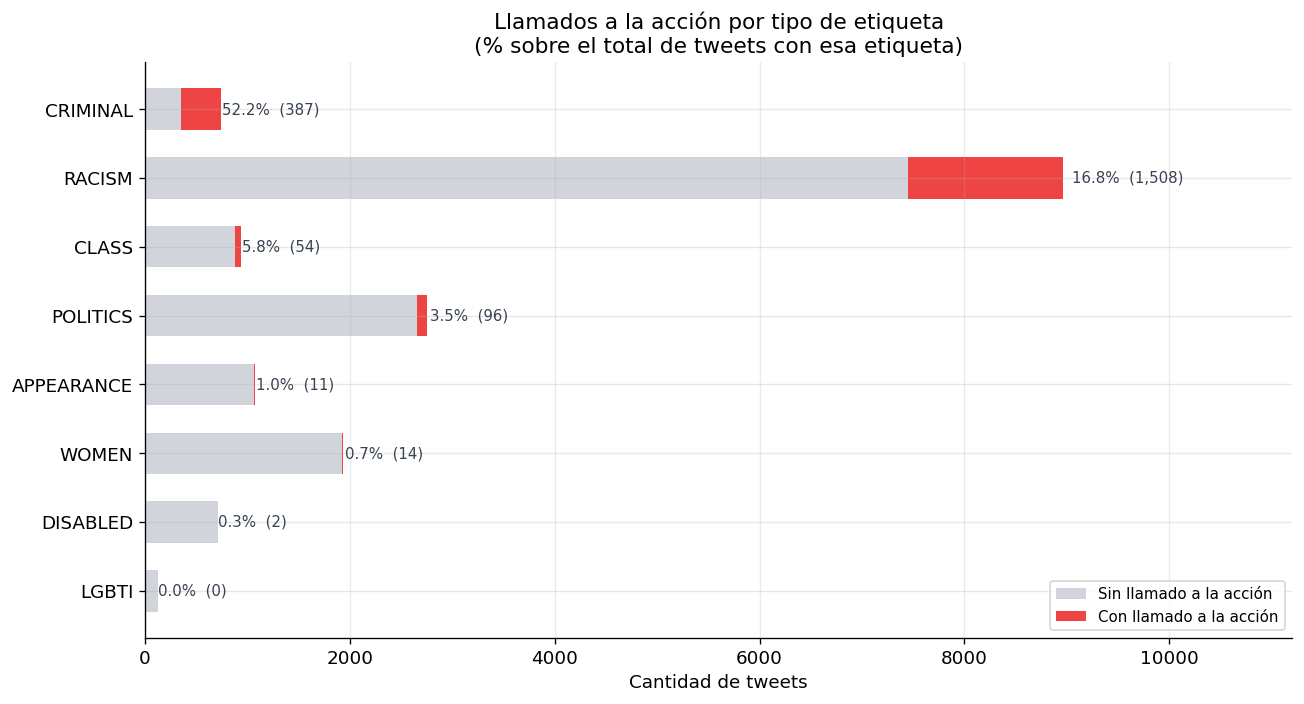

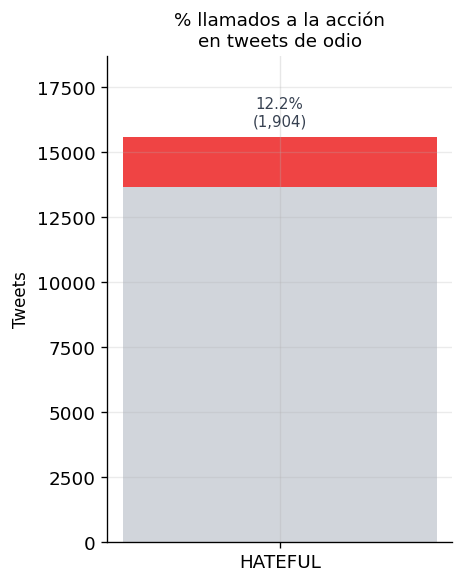

In [5]:
# Construir tabla: total por etiqueta y cuántos tienen CALLS
etiquetas_plot = HATEFUL_LABELS + ['HATEFUL']

calls_por_etiqueta = pd.DataFrame([
    {
        'etiqueta'            : lbl,
        'total'               : int(df[lbl].sum()),
        'llamados a la accion': int(df[(df[lbl] == 1) & (df['CALLS'] == 1)].shape[0]),
    }
    for lbl in etiquetas_plot
])
calls_por_etiqueta['% llamados'] = (
    calls_por_etiqueta['llamados a la accion'] / calls_por_etiqueta['total'] * 100
).round(1).fillna(0)

# Gráfico de llamados a la acción por etiqueta (sin HATEFUL)
sorted_pct = (calls_por_etiqueta[calls_por_etiqueta['etiqueta'] != 'HATEFUL']
              .sort_values('% llamados', ascending=True)
              .reset_index(drop=True))

hateful_row = calls_por_etiqueta[calls_por_etiqueta['etiqueta'] == 'HATEFUL'].iloc[0]

sin_calls = sorted_pct['total'] - sorted_pct['llamados a la accion']
con_calls = sorted_pct['llamados a la accion']

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(sorted_pct['etiqueta'], sin_calls, color='#d1d5db', label='Sin llamado a la acción', height=0.6)
ax.barh(sorted_pct['etiqueta'], con_calls, left=sin_calls, color='#ef4444', label='Con llamado a la acción', height=0.6)
for i, (_, row) in enumerate(sorted_pct.iterrows()):
    ax.text(row['total'] + row['total'] * 0.01, i,
            f"{row['% llamados']}%  ({int(row['llamados a la accion']):,})",
            va='center', ha='left', fontsize=9, color='#374151')
ax.set_xlim(0, sorted_pct['total'].max() * 1.25)
ax.set_xlabel('Cantidad de tweets', fontsize=11)
ax.set_title('Llamados a la acción por tipo de etiqueta\n(% sobre el total de tweets con esa etiqueta)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.savefig('outputs/DNU_calls_por_etiqueta.png', dpi=150)
plt.show()

# Gráfico HATEFUL aparte
sin_h = hateful_row['total'] - hateful_row['llamados a la accion']
con_h = hateful_row['llamados a la accion']

fig, ax = plt.subplots(figsize=(4, 5))
ax.bar(['HATEFUL'], [sin_h], color='#d1d5db', width=0.4)
ax.bar(['HATEFUL'], [con_h], bottom=[sin_h], color='#ef4444', width=0.4)
ax.text(0, hateful_row['total'] * 1.02,
        f"{hateful_row['% llamados']}%\n({int(con_h):,})",
        ha='center', va='bottom', fontsize=9, color='#374151')
ax.set_ylim(0, hateful_row['total'] * 1.2)
ax.set_ylabel('Tweets', fontsize=10)
ax.set_title('% llamados a la acción\nen tweets de odio', fontsize=11)
ax.grid(axis='y', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.savefig('outputs/DNU_calls_hateful.png', dpi=150)
plt.show()

Ejemplos

In [6]:
from IPython.display import display, HTML

ALL_LABELS = HATEFUL_LABELS + ['CALLS']
SEED       = 76    # ← cambiá este valor para explorar distintos ejemplos
N_HILOS    = 2

df['id_str_clean'] = df['id'].astype(str)
id_index = df.set_index('id_str_clean')

replies = df[df['in_reply_to_status_id'].notna()].copy()
replies['reply_target'] = replies['in_reply_to_status_id'].apply(lambda x: str(int(x)))
replies_encontrados = replies[replies['reply_target'].isin(id_index.index)]

root_ids = replies_encontrados['reply_target'].unique()
sample_roots = pd.Series(root_ids).sample(min(N_HILOS, len(root_ids)), random_state=SEED).tolist()

LABEL_COLORS = {
    'RACISM':'#dc2626','CRIMINAL':'#7c3aed','CALLS':'#ea580c',
    'POLITICS':'#2563eb','WOMEN':'#db2777','LGBTI':'#0891b2',
    'CLASS':'#65a30d','DISABLED':'#d97706','APPEARANCE':'#6b7280',
}

def badge(label):
    color = LABEL_COLORS.get(label, '#374151')
    return (f'<span style="background:{color};color:white;border-radius:4px;'
            f'padding:2px 7px;font-size:11px;margin:2px;display:inline-block">{label}</span>')

def tweet_card(row, is_root=False):
    activas = [l for l in ALL_LABELS if row[l] == 1]
    badges  = ''.join(badge(l) for l in activas) if activas else '<i style="color:#9ca3af">sin etiqueta</i>'
    fecha   = str(row['fecha_dia'])[:10]
    texto   = str(row['text'])[:280]
    bg      = '#f0f9ff' if is_root else '#ffffff'
    border  = '2px solid #3b82f6' if is_root else '1px solid #e5e7eb'
    prefix  = '<b>🔵 RAÍZ</b> &nbsp;' if is_root else '↳ &nbsp;'
    return (f'<div style="background:{bg};border:{border};border-radius:8px;'
            f'padding:10px 14px;margin:6px 0 6px {"0" if is_root else "24px"}">'
            f'<div style="font-size:11px;color:#6b7280;margin-bottom:4px">{prefix}📅 {fecha}</div>'
            f'<div style="font-size:13px;margin-bottom:6px">{texto}</div>'
            f'<div>{badges}</div>'
            f'</div>')

html_parts = []
for root_id in sample_roots:
    root  = id_index.loc[root_id]
    hijos = replies_encontrados[replies_encontrados['reply_target'] == root_id]
    html_parts.append(
        f'<div style="border:2px solid #cbd5e1;border-radius:10px;padding:14px;margin:16px 0">'
        f'<div style="font-size:12px;color:#94a3b8;margin-bottom:6px">HILO — {len(hijos)} reply/s en el dataset</div>'
        + tweet_card(root, is_root=True)
        + ''.join(tweet_card(h, is_root=False) for _, h in hijos.iterrows())
        + '</div>'
    )

display(HTML('\n'.join(html_parts)))

In [7]:
# Hilos donde al menos un reply tiene etiqueta  (usa SEED y N_HILOS de la celda anterior)
root_ids_etiq = [
    rid for rid in root_ids
    if replies_encontrados[
        (replies_encontrados['reply_target'] == rid) &
        (replies_encontrados[ALL_LABELS].any(axis=1))
    ].shape[0] > 0
]

print(f"Hilos con al menos un reply etiquetado: {len(root_ids_etiq)} / {len(root_ids)}")

sample_roots_etiq = pd.Series(root_ids_etiq).sample(min(N_HILOS, len(root_ids_etiq)), random_state=SEED).tolist()

html_parts = []
for root_id in sample_roots_etiq:
    root  = id_index.loc[root_id]
    hijos = replies_encontrados[replies_encontrados['reply_target'] == root_id]
    html_parts.append(
        f'<div style="border:2px solid #cbd5e1;border-radius:10px;padding:14px;margin:16px 0">'
        f'<div style="font-size:12px;color:#94a3b8;margin-bottom:6px">HILO — {len(hijos)} reply/s en el dataset</div>'
        + tweet_card(root, is_root=True)
        + ''.join(tweet_card(h, is_root=False) for _, h in hijos.iterrows())
        + '</div>'
    )

display(HTML('\n'.join(html_parts)))

Hilos con al menos un reply etiquetado: 39 / 281


Duplicados en el dataset\n\nVerificamos duplicados por `id` (tweet exacto) y por `text` (mismo contenido, distintos IDs — típico de RTs masivos)."

In [8]:
total = len(df)

# Duplicados por ID exacto
dup_id   = df.duplicated(subset='id')
n_dup_id = dup_id.sum()

# Duplicados por texto (mismo contenido, distintos IDs)
dup_text   = df.duplicated(subset='text')
n_dup_text = dup_text.sum()

# Duplicados por texto solo entre RTs (los más esperados)
rts = df[df['text'].str.startswith('RT', na=False)]
n_dup_rt = rts.duplicated(subset='text').sum()

print(f"Total tweets          : {total:,}")
print()
print(f"Duplicados por ID     : {n_dup_id:,}  ({n_dup_id/total*100:.1f}%)")
print(f"Duplicados por texto  : {n_dup_text:,}  ({n_dup_text/total*100:.1f}%)")
print(f"  └ de los cuales son RTs: {n_dup_rt:,}")
print()
print(f"Tweets únicos por ID  : {total - n_dup_id:,}")
print(f"Tweets únicos por texto: {total - n_dup_text:,}")

# Top textos más repetidos
top_dup = (
    df[df.duplicated(subset='text', keep=False)]
    .groupby('text')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='repeticiones')
    .head(10)
)
top_dup['text_corto'] = top_dup['text'].str[:100]
print(f"\nTop 10 textos más repetidos:")
print(top_dup[['repeticiones', 'text_corto']].to_string(index=False))

Total tweets          : 259,752

Duplicados por ID     : 135  (0.1%)
Duplicados por texto  : 178,752  (68.8%)
  └ de los cuales son RTs: 178,485

Tweets únicos por ID  : 259,617
Tweets únicos por texto: 81,000

Top 10 textos más repetidos:
 repeticiones                                                                                            text_corto
         6258  RT @maquialifraco: Argentina, el país que exporta jóvenes profesionales e importa delincuentes. http
         4982  RT @MiguelPichetto: No hay que permitir el ingreso de extranjeros con antecedentes penales a la Arge
         4035  RT @PatoBullrich: El presidente le manda un mensaje a los delincuentes y a los narcos. Al gobierno n
         3031  RT @JorgeFaurie: Grave error anular Decreto que autorizaba  expulsión extranjeros condenados. Los ar
         2887  RT @jorgemacri: Hace un año liberaron a los presos y ahora dejan entrar delincuentes y narcos. Una v
         2407  RT @PatoBullrich: Llegamos al "país" de Formosa. 

## Tipos de tweet: originales, RTs y menciones

,total,sin_etiq,HATEFUL,RACISM,CALLS,% sin etiq,% HATEFUL,% RACISM,% CALLS
tipo,,,,,,,,,
RT,"196,291","185,979","10,269","6,754","1,432",94.7%,5.2%,3.4%,0.7%
Mención/Reply,"35,704","32,461","3,208","1,269",341,90.9%,9.0%,3.6%,1.0%
Original,"27,757","25,627","2,090",939,249,92.3%,7.5%,3.4%,0.9%


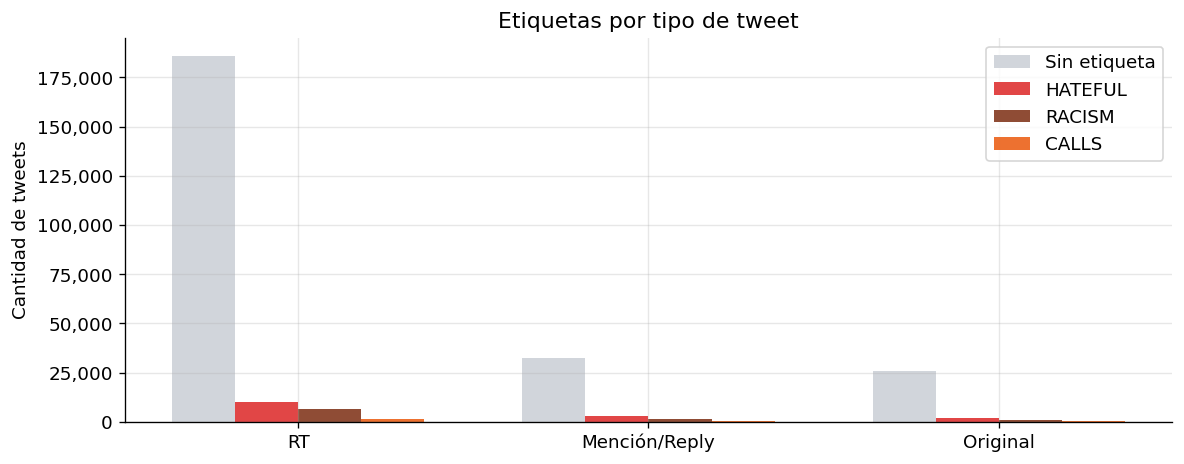

In [18]:
# Clasificar tipo de tweet
def tipo_tweet(row):
    if str(row['text']).startswith('RT '):
        return 'RT'
    elif pd.notna(row['in_reply_to_status_id']) or str(row['text']).startswith('@'):
        return 'Mención/Reply'
    else:
        return 'Original'

df['tipo'] = df.apply(tipo_tweet, axis=1)

# Tabla: tipo × etiquetas
resumen_tipo = (
    df.groupby('tipo')
    .agg(
        total    = ('tipo', 'count'),
        sin_etiq = ('n_labels', lambda x: (x == 0).sum()),
        HATEFUL  = ('HATEFUL', 'sum'),
        RACISM   = ('RACISM',  'sum'),
        CALLS    = ('CALLS',   'sum'),
    )
    .reset_index()
    .sort_values('total', ascending=False)
)
resumen_tipo['% sin etiq'] = (resumen_tipo['sin_etiq'] / resumen_tipo['total'] * 100).round(1)
resumen_tipo['% HATEFUL']  = (resumen_tipo['HATEFUL']  / resumen_tipo['total'] * 100).round(1)
resumen_tipo['% RACISM']   = (resumen_tipo['RACISM']   / resumen_tipo['total'] * 100).round(1)
resumen_tipo['% CALLS']    = (resumen_tipo['CALLS']    / resumen_tipo['total'] * 100).round(1)

display(
    resumen_tipo
    .set_index('tipo')
    .style
    .format({'total': '{:,}', 'sin_etiq': '{:,}', 'HATEFUL': '{:,}', 'RACISM': '{:,}', 'CALLS': '{:,}',
             '% sin etiq': '{:.1f}%', '% HATEFUL': '{:.1f}%', '% RACISM': '{:.1f}%', '% CALLS': '{:.1f}%'})
    .background_gradient(subset=['% HATEFUL'], cmap='Reds')
    .background_gradient(subset=['% RACISM'],  cmap='RdPu')
    .background_gradient(subset=['% CALLS'],   cmap='Oranges')
    .background_gradient(subset=['total'],      cmap='Blues')
    .set_caption('Distribución por tipo de tweet')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]
    }])
)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
tipos = resumen_tipo['tipo']
x = range(len(tipos))
w = 0.18
offsets = [-1.5 * w, -0.5 * w, 0.5 * w, 1.5 * w]
ax.bar([i + offsets[0] for i in x], resumen_tipo['sin_etiq'], width=w, label='Sin etiqueta', color='#d1d5db')
ax.bar([i + offsets[1] for i in x], resumen_tipo['HATEFUL'],  width=w, label='HATEFUL',      color='#dc2626', alpha=0.85)
ax.bar([i + offsets[2] for i in x], resumen_tipo['RACISM'],   width=w, label='RACISM',       color='#7c2d12', alpha=0.85)
ax.bar([i + offsets[3] for i in x], resumen_tipo['CALLS'],    width=w, label='CALLS',        color='#ea580c', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(tipos)
ax.set_ylabel('Cantidad de tweets')
ax.set_title('Etiquetas por tipo de tweet')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('outputs/DNU_tipos_tweet.png', dpi=150)
plt.show()

In [10]:
# Top 10 textos más retuiteados
top_rts = (
    df[df['tipo'] == 'RT']
    .groupby('text')
    .agg(
        veces_rt = ('id', 'nunique'),
        HATEFUL  = ('HATEFUL', 'first'),
        CALLS    = ('CALLS', 'first'),
        fecha_min = ('fecha_dia', 'min'),
        fecha_max = ('fecha_dia', 'max'),
    )
    .reset_index()
    .sort_values('veces_rt', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_rts['text_corto'] = top_rts['text'].str[:120]
top_rts['span_dias']  = (pd.to_datetime(top_rts['fecha_max']) - pd.to_datetime(top_rts['fecha_min'])).dt.days

html_parts = []
for i, row in top_rts.iterrows():
    hateful_badge = badge('HATEFUL') if row['HATEFUL'] else ''
    calls_badge   = badge('CALLS')   if row['CALLS']   else ''
    etiq = (hateful_badge + calls_badge) or '<i style="color:#9ca3af">sin etiqueta</i>'
    span = f"{row['span_dias']} día/s" if row['span_dias'] > 0 else 'mismo día'
    html_parts.append(
        f'<div style="border:1px solid #e5e7eb;border-radius:8px;padding:10px 14px;margin:6px 0;'
        f'border-left:4px solid #dc2626">'
        f'<div style="display:flex;justify-content:space-between;margin-bottom:4px">'
        f'<span style="font-weight:bold;font-size:13px">#{i+1} — {row["veces_rt"]:,} RTs</span>'
        f'<span style="font-size:11px;color:#6b7280">📅 {row["fecha_min"]} → {row["fecha_max"]} ({span})</span>'
        f'</div>'
        f'<div style="font-size:13px;margin-bottom:6px">{row["text_corto"]}…</div>'
        f'<div>{etiq}</div>'
        f'</div>'
    )

display(HTML('\n'.join(html_parts)))

Top menciones más repetidas

In [21]:
# Top 10 textos de menciones/replies más repetidos
top_menciones = (
    df[df['tipo'] == 'Mención/Reply']
    .groupby('text')
    .agg(
        veces     = ('id', 'nunique'),
        HATEFUL   = ('HATEFUL', 'first'),
        RACISM    = ('RACISM',  'first'),
        CALLS     = ('CALLS',   'first'),
        fecha_min = ('fecha_dia', 'min'),
        fecha_max = ('fecha_dia', 'max'),
    )
    .reset_index()
    .sort_values('veces', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_menciones['text_corto'] = top_menciones['text'].str[:120]
top_menciones['span_dias']  = (pd.to_datetime(top_menciones['fecha_max']) - pd.to_datetime(top_menciones['fecha_min'])).dt.days
# Usuario mencionado: primer @user del texto
top_menciones['mencionado'] = top_menciones['text'].str.extract(r'@(\w+)', expand=False)

html_parts = []
for i, row in top_menciones.iterrows():
    hateful_badge = badge('HATEFUL') if row['HATEFUL'] else ''
    racism_badge  = badge('RACISM')  if row['RACISM']  else ''
    calls_badge   = badge('CALLS')   if row['CALLS']   else ''
    etiq = (hateful_badge + racism_badge + calls_badge) or '<i style="color:#9ca3af">sin etiqueta</i>'
    span = f"{row['span_dias']} día/s" if row['span_dias'] > 0 else 'mismo día'
    mencionado = f'<span style="font-size:11px;color:#2563eb;margin-left:8px">@{row["mencionado"]}</span>' if pd.notna(row['mencionado']) else ''
    html_parts.append(
        f'<div style="border:1px solid #e5e7eb;border-radius:8px;padding:10px 14px;margin:6px 0;'
        f'border-left:4px solid #2563eb">'
        f'<div style="display:flex;justify-content:space-between;margin-bottom:4px">'
        f'<span style="font-weight:bold;font-size:13px">#{i+1} — {row["veces"]:,} apariciones{mencionado}</span>'
        f'<span style="font-size:11px;color:#6b7280">📅 {row["fecha_min"]} → {row["fecha_max"]} ({span})</span>'
        f'</div>'
        f'<div style="font-size:13px;margin-bottom:6px">{row["text_corto"]}…</div>'
        f'<div>{etiq}</div>'
        f'</div>'
    )

display(HTML('\n'.join(html_parts)))

In [22]:
TOP_USERS_MEN = 30

# Extraer primer @usuario mencionado en cada tweet de tipo Mención/Reply
menciones = df[df['tipo'] == 'Mención/Reply'].copy()
menciones['usuario_men'] = menciones['text'].str.extract(r'@(\w+)', expand=False)

usuarios_men = (
    menciones[menciones['usuario_men'].notna()]
    .groupby('usuario_men')
    .agg(
        menciones  = ('id',      'count'),
        n_hateful  = ('HATEFUL', 'sum'),
        n_racism   = ('RACISM',  'sum'),
    )
    .reset_index()
    .sort_values('menciones', ascending=False)
    .head(TOP_USERS_MEN)
)
usuarios_men['% HATEFUL'] = (usuarios_men['n_hateful'] / usuarios_men['menciones'] * 100).round(1)
usuarios_men['% RACISM']  = (usuarios_men['n_racism']  / usuarios_men['menciones'] * 100).round(1)

display(
    usuarios_men
    .set_index('usuario_men')
    .style
    .format({'menciones': '{:,}', 'n_hateful': '{:,}', 'n_racism': '{:,}',
             '% HATEFUL': '{:.1f}%', '% RACISM': '{:.1f}%'})
    .background_gradient(subset=['menciones'],  cmap='Blues')
    .background_gradient(subset=['% HATEFUL'], cmap='Reds')
    .background_gradient(subset=['% RACISM'],  cmap='RdPu')
    .set_caption(f'Top {TOP_USERS_MEN} usuarios más mencionados — tasa de odio y racismo')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]
    }])
)

,menciones,n_hateful,n_racism,% HATEFUL,% RACISM
usuario_men,,,,,
EliGAlcorta,"1,337",100,69,7.5%,5.2%
alferdez,380,9,6,2.4%,1.6%
biobio,325,42,13,12.9%,4.0%
todonoticias,315,28,17,8.9%,5.4%
edufeiok,217,17,8,7.8%,3.7%
infobae,213,10,6,4.7%,2.8%
MiguelPichetto,183,7,2,3.8%,1.1%
T13,180,43,17,23.9%,9.4%
Cooperativa,170,30,8,17.6%,4.7%


Exploración de usuarios\n\n⚠️ El dataset no tiene columna de autor. Para los **retweets** se extrae el usuario del patrón `RT @usuario:` — este es el **autor del tweet original** (el más retuiteado), no quien retwittea. Para tweets directos y replies el autor es desconocido."

In [11]:
import re

# Extraer usuario de RTs: "RT @usuario: ..."
df['rt_user'] = df['text'].str.extract(r'^RT @(\w+):', expand=False)

# Agrupar por usuario extraído
user_stats = (
    df[df['rt_user'].notna()]
    .groupby('rt_user')
    .agg(
        tweets    = ('rt_user', 'count'),
        hateful   = ('HATEFUL', 'sum'),
        calls     = ('CALLS', 'sum'),
    )
    .reset_index()
    .sort_values('tweets', ascending=False)
)
user_stats['% hateful'] = (user_stats['hateful'] / user_stats['tweets'] * 100).round(1)
user_stats['% calls']   = (user_stats['calls']   / user_stats['tweets'] * 100).round(1)

n_rt  = df['rt_user'].notna().sum()
n_unk = df['rt_user'].isna().sum()
print(f"Tweets con usuario extraído : {n_rt:,}  ({n_rt/len(df)*100:.1f}%)")
print(f"Tweets sin usuario (directos/replies): {n_unk:,}  ({n_unk/len(df)*100:.1f}%)")
print(f"Usuarios únicos: {len(user_stats):,}\n")

TOP = 30
display(
    user_stats.head(TOP)
    .style
    .format({'tweets': '{:,}', 'hateful': '{:,}', 'calls': '{:,}',
             '% hateful': '{:.1f}%', '% calls': '{:.1f}%'})
    .background_gradient(subset=['tweets'], cmap='Blues')
    .background_gradient(subset=['% hateful'], cmap='Reds')
    .background_gradient(subset=['% calls'], cmap='Oranges')
    .set_caption(f'Top {TOP} usuarios más retuiteados')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]
    }])
)

Tweets con usuario extraído : 196,282  (75.6%)
Tweets sin usuario (directos/replies): 63,470  (24.4%)
Usuarios únicos: 12,742



,rt_user,tweets,hateful,calls,% hateful,% calls
5403,PatoBullrich,"6,442",0,0,0.0%,0.0%
10577,maquialifraco,"6,363",0,0,0.0%,0.0%
4744,MiguelPichetto,"4,982",0,0,0.0%,0.0%
3437,JorgeFaurie,"3,031",0,0,0.0%,0.0%
9802,jorgemacri,"2,887",0,0,0.0%,0.0%
12352,todonoticias,"2,802",0,0,0.0%,0.0%
9037,florenciarietto,"2,408",51,2,2.1%,0.1%
10439,luispetri,"2,079",0,0,0.0%,0.0%
7008,WolffWaldo,"1,974",0,0,0.0%,0.0%
11724,rctagliaferro,"1,970",0,0,0.0%,0.0%


In [23]:
USUARIOS_BUSCAR = ['baradit', 'madorni','baradit','MiguelPichetto']
N_EJEMPLOS_USER = 10

patron = '|'.join([rf'@{u}' for u in USUARIOS_BUSCAR])
mask   = df['text'].str.contains(patron, case=False, na=False)
df_mencionados = df[mask].copy()

# Contar cuántas veces fue retuiteado cada texto único
rt_counts = (
    df_mencionados.groupby('text')['id']
    .nunique()
    .rename('n_rts')
    .reset_index()
)
# Quedarse con un representante por texto (el primero), agregar conteo de RTs
df_unicos = (
    df_mencionados
    .drop_duplicates(subset='text', keep='first')
    .merge(rt_counts, on='text', how='left')
)

print(f"Tweets que mencionan a {USUARIOS_BUSCAR}: {len(df_mencionados):,}  →  textos únicos: {len(df_unicos):,}")
for u in USUARIOS_BUSCAR:
    n_total  = df['text'].str.contains(f'@{u}', case=False, na=False).sum()
    n_unicos = df[df['text'].str.contains(f'@{u}', case=False, na=False)].drop_duplicates('text').shape[0]
    print(f"  @{u}: {n_total:,} apariciones  /  {n_unicos:,} textos únicos")

muestra_users = df_unicos.sample(min(N_EJEMPLOS_USER, len(df_unicos)), random_state=SEED)

html_parts = []
for _, row in muestra_users.iterrows():
    texto = str(row['text'])[:280]
    for u in USUARIOS_BUSCAR:
        texto = re.sub(rf'(@{u})', r'<b style="color:#2563eb">\1</b>', texto, flags=re.IGNORECASE)

    activas = [l for l in ALL_LABELS if row[l] == 1]
    badges  = ''.join(badge(l) for l in activas) if activas else '<i style="color:#9ca3af">sin etiqueta</i>'
    fecha   = str(row['fecha_dia'])[:10]
    is_rt   = str(row['text']).startswith('RT')
    tipo    = '🔁 RT' if is_rt else '💬 Tweet'

    n_rts = int(row['n_rts'])
    rt_label = ''
    if n_rts > 1:
        rt_label = (f'<span style="background:#f1f5f9;border:1px solid #cbd5e1;border-radius:4px;'
                    f'padding:2px 8px;font-size:11px;margin-left:6px">🔁 {n_rts:,} veces retuiteado</span>')

    html_parts.append(
        f'<div style="border:1px solid #e5e7eb;border-radius:8px;padding:10px 14px;margin:6px 0">'
        f'<div style="font-size:11px;color:#6b7280;margin-bottom:4px">'
        f'📅 {fecha} &nbsp; {tipo}{rt_label}'
        f'</div>'
        f'<div style="font-size:13px;margin-bottom:6px">{texto}</div>'
        f'<div>{badges}</div>'
        f'</div>'
    )

display(HTML('\n'.join(html_parts)))

Tweets que mencionan a ['baradit', 'madorni', 'baradit', 'MiguelPichetto']: 8,283  →  textos únicos: 333
  @baradit: 1,498 apariciones  /  24 textos únicos
  @madorni: 1,344 apariciones  /  47 textos únicos
  @baradit: 1,498 apariciones  /  24 textos únicos
  @MiguelPichetto: 5,441 apariciones  /  262 textos únicos


In [ ]:
import nbformat
from nbconvert import HTMLExporter
from datetime import date

nb_path  = '2_DNU_EDA.ipynb'
out_path = f'outputs/2_DNU_EDA_{date.today()}.html'

with open(nb_path, encoding='utf-8') as f:
    nb_node = nbformat.read(f, as_version=4)

body, _ = HTMLExporter().from_notebook_node(nb_node)

with open(out_path, 'w', encoding='utf-8') as f:
    
    f.write(body)

print(f'Guardado: {out_path} ({len(body)//1024} KB)')

Guardado: outputs/2_DNU_EDA_2026-04-09.html (647 KB)
